# CPU Benchmark Analysis — Value Analysis

In this notebook we go beyond predicting benchmark scores and ask a different
question — which CPUs offer the best performance per dollar?

A high benchmark score does not always mean good value. A CPU scoring 20,000
for $150 is a far better buy than one scoring 22,000 for $800. The goal here
is to identify which CPUs, categories, and price brackets offer the most
benchmark performance for the money.

This analysis uses the cleaned dataset produced in Notebook 2.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = '/content/drive/MyDrive/CPU Project/'
df = pd.read_csv(path + 'CPU_benchmark_cleaned.csv')

print("Dataset loaded successfully")
print(f"Shape: {df.shape}")

Mounted at /content/drive
Dataset loaded successfully
Shape: (3825, 9)


------

## Step 1 — Calculate Value Score

The value score is calculated by dividing cpuMark by price.
A higher value score means more benchmark performance per dollar spent.

We exclude CPUs with a price of zero or missing since these would
produce infinite or meaningless value scores.

In [2]:
# Calculate value score — benchmark performance per dollar
# We filter out any rows where price is zero to avoid division errors

df_value = df[df['price'] > 0].copy()
df_value['value_score'] = df_value['cpuMark'] / df_value['price']

print(f"CPUs with valid price data: {len(df_value)}")
print()
print("Value score summary:")
print(df_value['value_score'].describe().round(2))

CPUs with valid price data: 3825

Value score summary:
count    3825.00
mean       30.57
std        44.86
min         0.22
25%         7.17
50%        17.53
75%        37.47
max       940.80
Name: value_score, dtype: float64


------

## Step 2 — Top Value CPUs Overall

Before breaking down by category we look at the top 10 best value CPUs
across the entire dataset. These are the CPUs that deliver the most
benchmark performance per dollar regardless of type or price range.

In [3]:
# Top 10 best value CPUs overall

top_value = df_value.nlargest(10, 'value_score')[
    ['cpuName', 'category', 'cores', 'price', 'cpuMark', 'value_score']
].reset_index(drop=True)

top_value['value_score'] = top_value['value_score'].round(2)

print("Top 10 Best Value CPUs")
print()
print(top_value.to_string(index=False))

Top 10 Best Value CPUs

                          cpuName category  cores  price  cpuMark  value_score
AMD Ryzen Threadripper PRO 5995WX  Desktop     64 115.67   108822       940.80
AMD Ryzen Threadripper PRO 5975WX  Desktop     32 115.67    80842       698.90
AMD Ryzen Threadripper PRO 5965WX  Desktop     24 115.67    68405       591.38
 ARM Neoverse-N1 80 Core 3000 MHz    Other     80  64.99    38122       586.58
    ARM Neoverse-N1 80 Core 0 MHz    Other     80  64.99    37809       581.77
AMD Ryzen Threadripper PRO 5955WX  Desktop     16 115.67    51656       446.58
    ARM Neoverse-N1 64 Core 0 MHz    Other     64  64.99    28079       432.05
AMD Ryzen Threadripper PRO 5945WX  Desktop     12 115.67    41578       359.45
           Apple M1 Ultra 20 Core  Desktop     16 115.67    41360       357.57
  Intel Xeon E5-1603 v3 @ 2.80GHz   Server      4  12.88     4448       345.34


### Data Quality Issue — Suspicious Prices

The top value CPUs are dominated by high end Threadripper PRO chips showing
a price of $115.67 — clearly incorrect for CPUs that retail between $3,000
and $8,000. These appear to be data entry errors in the original dataset.

Including these would severely distort the value analysis. We filter them out
by removing CPUs where the price seems implausibly low relative to their
benchmark score. We define suspicious entries as CPUs scoring above 10,000
but priced below $200.

In [4]:
# Remove suspicious entries — high performing CPUs with implausibly low prices
# CPUs scoring above 10,000 but priced below $200 are likely data errors

df_clean_value = df_value[
    ~((df_value['cpuMark'] > 10000) & (df_value['price'] < 200))
].copy()

print(f"CPUs before filtering : {len(df_value)}")
print(f"CPUs after filtering  : {len(df_clean_value)}")
print(f"Suspicious rows removed: {len(df_value) - len(df_clean_value)}")

CPUs before filtering : 3825
CPUs after filtering  : 3659
Suspicious rows removed: 166


In [5]:
# Recalculate value score on the filtered dataset
df_clean_value['value_score'] = df_clean_value['cpuMark'] / df_clean_value['price']

# Top 10 best value CPUs after removing suspicious prices
top_value_clean = df_clean_value.nlargest(10, 'value_score')[
    ['cpuName', 'category', 'cores', 'price', 'cpuMark', 'value_score']
].reset_index(drop=True)

top_value_clean['value_score'] = top_value_clean['value_score'].round(2)

print("Top 10 Best Value CPUs (Cleaned)")
print()
print(top_value_clean.to_string(index=False))

Top 10 Best Value CPUs (Cleaned)

                         cpuName category  cores   price  cpuMark  value_score
 Intel Xeon E5-1603 v3 @ 2.80GHz   Server      4  12.880     4448       345.34
    Intel Xeon E5-1607 @ 3.00GHz   Server      4  11.530     3730       323.50
Intel Xeon E5-1428L v2 @ 2.20GHz   Server      6  20.370     6566       322.34
                AMD Opteron 6220   Server      4  14.820     4753       320.72
                AMD Opteron 4284   Server      4  14.820     4665       314.78
 Intel Xeon E5-1410 v2 @ 2.80GHz   Server      4  19.200     5842       304.27
               AMD A6-3410MX APU   Laptop      4   3.990     1199       300.50
                AMD Opteron 2435   Server      6  10.950     3061       279.54
                   AMD EPYC 7J13   Server     64 338.885    86006       253.79
      Intel Xeon X5667 @ 3.07GHz   Server      4  18.040     4551       252.27


## Step 6 — Remove Suspicious Price Entries

High performing CPUs scoring above 10,000 but priced below $200 appear to be
data entry errors in the original dataset. These are removed before saving
to ensure the cleaned dataset used in the app reflects accurate pricing.

In [6]:
# Remove CPUs with suspiciously low prices relative to their benchmark score
before = len(df)
df = df[~((df['cpuMark'] > 10000) & (df['price'] < 200))]
after = len(df)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Removed     : {before - after} suspicious pricing entries")

Rows before : 3825
Rows after  : 3659
Removed     : 166 suspicious pricing entries


In [7]:
df.to_csv(path + 'CPU_benchmark_cleaned.csv', index=False)
print("Cleaned dataset saved successfully")
print(f"Shape: {df.shape}")

Cleaned dataset saved successfully
Shape: (3659, 9)


In [8]:
# Top 5 best value CPUs per category

categories = ['Desktop', 'Laptop', 'Server', 'Other']

for cat in categories:
    cat_df = df_clean_value[df_clean_value['category'] == cat]
    top_cat = cat_df.nlargest(5, 'value_score')[
        ['cpuName', 'cores', 'price', 'cpuMark', 'value_score']
    ].reset_index(drop=True)
    top_cat['value_score'] = top_cat['value_score'].round(2)

    print(f"Top 5 Best Value — {cat}")
    print()
    print(top_cat.to_string(index=False))
    print()

Top 5 Best Value — Desktop

                       cpuName  cores  price  cpuMark  value_score
  AMD Athlon X4 760K Quad Core      2  13.55     2941       217.05
AMD Athlon II X4 631 Quad-Core      4   9.96     2085       209.34
       AMD FX-8370E Eight-Core      4  25.14     5235       208.23
AMD Athlon II X4 641 Quad-Core      4  12.33     2143       173.80
         AMD FX-4130 Quad-Core      2  22.21     2730       122.92

Top 5 Best Value — Laptop

                        cpuName  cores  price  cpuMark  value_score
              AMD A6-3410MX APU      4   3.99     1199       300.50
   AMD Phenom II N620 Dual-Core      2   3.99      990       248.12
           Intel Core i5-12500H      4 311.00    23530        75.66
Intel Core2 Duo T5750 @ 2.00GHz      2   9.99      667        66.77
 Intel Core i5-11500H @ 2.90GHz      6 250.00    16458        65.83

Top 5 Best Value — Server

                         cpuName  cores  price  cpuMark  value_score
 Intel Xeon E5-1603 v3 @ 2.80GHz     

### Best Value CPUs by Category — Findings

Breaking down value scores by category reveals some interesting patterns.

Desktop CPUs are led by older AMD budget chips available for under $25 on the
second hand market. These offer strong value for basic computing tasks but would
not be suitable for demanding workloads.

The Laptop category is mixed — some entries have suspiciously low prices
suggesting further data quality issues. Among realistically priced entries,
modern chips like the Intel Core i5-12500H offer strong value at $311 for
23,530 benchmark points.

Server CPUs consistently show strong value through older Xeon and Opteron
chips available cheaply second hand, echoing the findings from the overall
top 10 analysis.

The Other category shows repeated $64.99 prices across different CPUs,
suggesting placeholder pricing similar to the issue identified earlier.
These results should be interpreted with caution.

----

## Step 4 — Value Score Distribution by Category

We visualize how value scores are distributed across each category.
This tells us which category consistently offers the best performance
per dollar and how much variation exists within each group.

/tmp/ipykernel_4764/3042342776.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


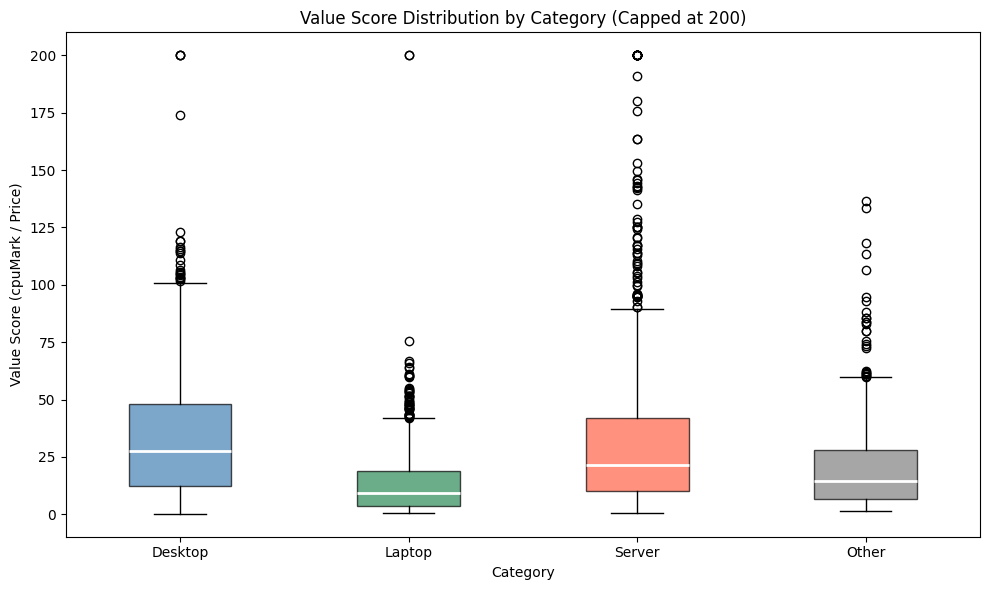

In [9]:
# Box plot of value scores by category
# We cap value scores at 200 for visualization clarity
# since extreme outliers compress the rest of the distribution

fig, ax = plt.subplots(figsize=(10, 6))

categories_order = ['Desktop', 'Laptop', 'Server', 'Other']
data_to_plot = [
    df_clean_value[df_clean_value['category'] == cat]['value_score'].clip(upper=200)
    for cat in categories_order
]

bp = ax.boxplot(
    data_to_plot,
    labels=categories_order,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2)
)

colors = ['steelblue', 'seagreen', 'tomato', 'gray']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Value Score Distribution by Category (Capped at 200)')
ax.set_xlabel('Category')
ax.set_ylabel('Value Score (cpuMark / Price)')

plt.tight_layout()
plt.show()

### Value Score Distribution — Findings

The box plot reveals clear differences in value across categories.

Desktop CPUs offer the highest and most consistent value with a median score
of around 25 benchmark points per dollar. The wide spread reflects the large
range of desktop CPUs from budget chips to high end enthusiast hardware.

Laptop CPUs offer the lowest value overall with a median around 10. This is
expected — laptop hardware commands a price premium for its compact and
power efficient design that is not reflected in raw benchmark scores.

Server CPUs show the widest distribution. The median sits around 20 but
numerous outliers above 100 reflect older server hardware available cheaply
on the second hand market — consistent with our earlier findings.

The key takeaway is that Desktop CPUs offer the best value for most consumers
while Laptop CPUs consistently deliver less performance per dollar spent.

---

## Step 5 — Value Score vs Price

We now look at how value score changes as price increases.
This tells us whether spending more always means better value
or whether there is a sweet spot in the price range.

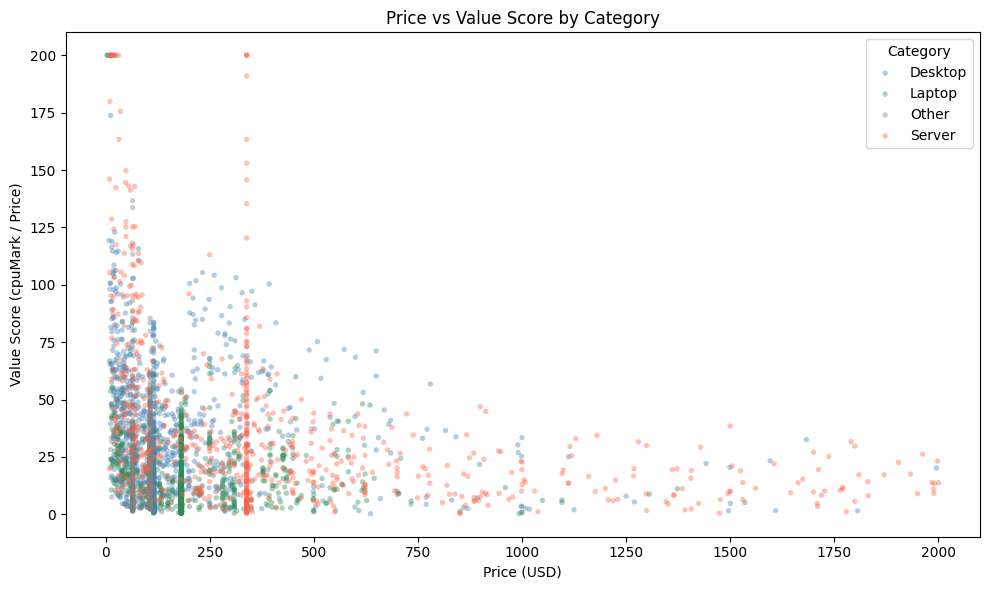

In [10]:
# Scatter plot of price vs value score colored by category
# We cap price at 2000 and value score at 200 for visualization clarity

fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    'Desktop' : 'steelblue',
    'Laptop'  : 'seagreen',
    'Server'  : 'tomato',
    'Other'   : 'gray'
}

for cat, group in df_clean_value.groupby('category'):
    group_filtered = group[group['price'] <= 2000]
    ax.scatter(
        group_filtered['price'],
        group_filtered['value_score'].clip(upper=200),
        c=colors.get(cat, 'gray'),
        label=cat,
        alpha=0.4,
        edgecolors='none',
        s=15
    )

ax.set_title('Price vs Value Score by Category')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Value Score (cpuMark / Price)')
ax.legend(title='Category')

plt.tight_layout()
plt.show()

### Price vs Value Score — Findings

The scatter plot reveals a clear diminishing returns pattern. Value scores are
highest at low price points and drop sharply as price increases, regardless
of category. The best value CPUs are almost entirely concentrated below $500.

Beyond $500 the value score flattens significantly — spending more money does
not proportionally increase benchmark performance. This suggests that for
most users, the optimal price range for value is between $50 and $300.

Server CPUs maintain relatively better value further up the price range
compared to Desktop and Laptop chips, reflecting the higher core counts
that server hardware offers at premium price points.

Laptop CPUs show consistently low value scores across all price points,
confirming that laptop hardware commands a price premium that is not
reflected in raw benchmark performance.

----

## Summary

This notebook identified which CPUs offer the best performance per dollar
across the dataset.

The key findings are:

Value scores follow a clear diminishing returns pattern — the best performance
per dollar is found below $500, with the sweet spot between $50 and $300.

Desktop CPUs offer the highest and most consistent value overall. Server CPUs
show the widest variation, with older second hand hardware offering exceptional
value. Laptop CPUs consistently deliver the least performance per dollar due
to the price premium on compact hardware.

These findings directly inform the Best Value Finder feature in the app,
where users can enter a budget and category to find the highest value CPUs
within their price range.